In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:

# Load the dataset
df = pd.read_csv(r'C:\Users\Gaurav verma\Desktop\Salary_predictor\Data\DataScience_salaries_2025.csv')

# Display the first 5 rows to understand what we are working with
display(df.head())

# Check for missing values and view data types
print("\nDataset Info:")
df.info()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93597 entries, 0 to 93596
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           93597 non-null  int64 
 1   experience_level    93597 non-null  object
 2   employment_type     93597 non-null  object
 3   job_title           93597 non-null  object
 4   salary              93597 non-null  int64 
 5   salary_currency     93597 non-null  object
 6   salary_in_usd       93597 non-null  int64 
 7   employee_residence  93597 non-null  object
 8   remote_ratio        93597 non-null  int64 
 9   company_location    93597 non-null  object
 10  company_size        93597 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.9+ MB


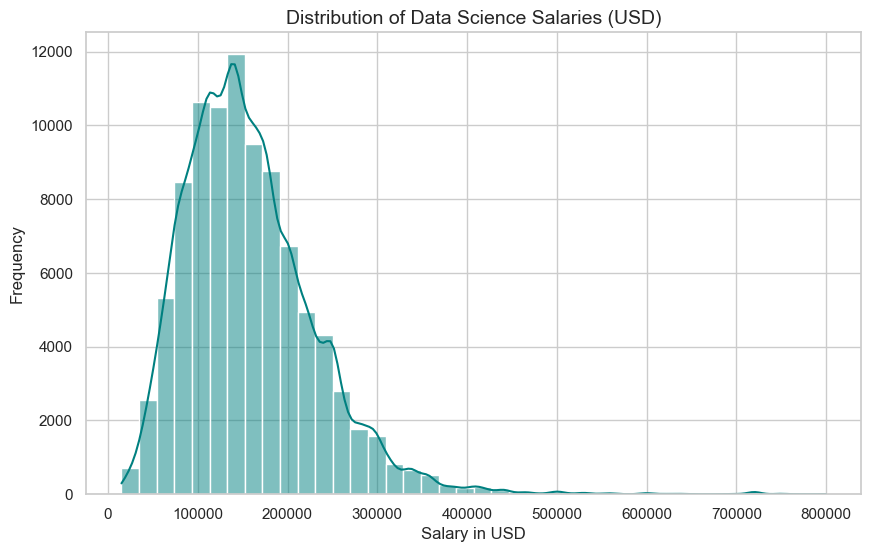

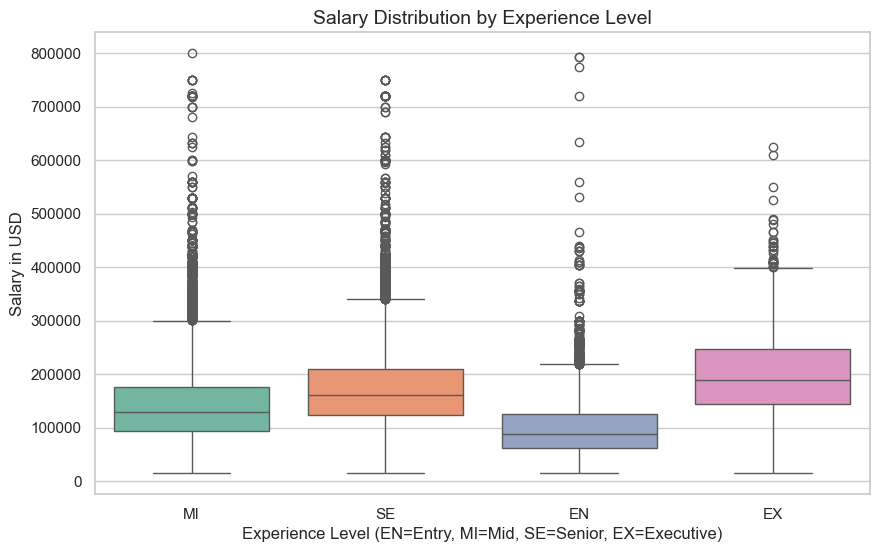

In [6]:

sns.set_theme(style="whitegrid")

# 1. Histogram of Salaries
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], bins=40, kde=True, color='teal')
plt.title('Distribution of Data Science Salaries (USD)', fontsize=14)
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.show()

# 2. Box Plot to spot outliers across experience levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, palette='Set2')
plt.title('Salary Distribution by Experience Level', fontsize=14)
plt.xlabel('Experience Level (EN=Entry, MI=Mid, SE=Senior, EX=Executive)')
plt.ylabel('Salary in USD')
plt.show()

In [8]:


# Select only the features that logically impact the salary
features_to_keep = ['experience_level', 'employment_type', 'job_title', 'company_location', 'salary_in_usd']
df_cleaned = df[features_to_keep].copy()

# Drop any rows with missing values
df_cleaned.dropna(inplace=True)

# --- Map Experience Level ---
exp_mapping = {
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior-level',
    'EX': 'Executive-level'
}
df_cleaned['experience_level'] = df_cleaned['experience_level'].replace(exp_mapping)

# --- Map Employment Type ---
emp_mapping = {
    'PT': 'Part-time',
    'FT': 'Full-time',
    'CT': 'Contract',
    'FL': 'Freelance'
}
df_cleaned['employment_type'] = df_cleaned['employment_type'].replace(emp_mapping)

# --- Map Company Location (Using a safe dictionary!) ---
country_mapping = {
    'US': 'United States', 'IN': 'India', 'GB': 'United Kingdom', 
    'CA': 'Canada', 'DE': 'Germany', 'FR': 'France', 'ES': 'Spain', 
    'GR': 'Greece', 'JP': 'Japan', 'PT': 'Portugal', 'BR': 'Brazil',
    'PK': 'Pakistan', 'NL': 'Netherlands', 'IT': 'Italy', 'RU': 'Russia',
    'AU': 'Australia', 'CH': 'Switzerland', 'AE': 'United Arab Emirates',
    'SG': 'Singapore', 'IE': 'Ireland', 'SE': 'Sweden', 'MX': 'Mexico',
    'CO': 'Colombia', 'AT': 'Austria', 'PL': 'Poland', 'NG': 'Nigeria'
}

def get_country_name(code):
    # This looks up the code in our dictionary. 
    # If it doesn't find it, it safely just returns the original code.
    return country_mapping.get(code, code) 

df_cleaned['company_location'] = df_cleaned['company_location'].apply(get_country_name)

print(f"Cleaned dataset shape: {df_cleaned.shape}")
display(df_cleaned.head())

Cleaned dataset shape: (93597, 5)


,experience_level,employment_type,job_title,company_location,salary_in_usd
0,Mid-level,Full-time,Research Scientist,United States,208000
1,Mid-level,Full-time,Research Scientist,United States,147000
2,Senior-level,Full-time,Research Scientist,United States,173000
3,Senior-level,Full-time,Research Scientist,United States,117000
4,Mid-level,Full-time,AI Engineer,United States,100000


In [9]:

encoders = {}
categorical_cols = ['experience_level', 'employment_type', 'job_title', 'company_location']

for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the text data into numbers
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    # Store the trained encoder
    encoders[col] = le 

print("Categorical features encoded successfully!")
display(df_cleaned.head())

Categorical features encoded successfully!


,experience_level,employment_type,job_title,company_location,salary_in_usd
0,2,2,282,84,208000
1,2,2,282,84,147000
2,3,2,282,84,173000
3,3,2,282,84,117000
4,2,2,4,84,100000


In [10]:

#  Split Data into Training and Testing Sets
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df_cleaned.drop('salary_in_usd', axis=1)
y = df_cleaned['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split successfully!")

Data split successfully!


In [11]:

#  Model Comparison (Linear Regression vs Random Forest)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Baseline Model: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# 2. Advanced Model: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Compare Results
print("--- Model Evaluation ---")
print(f"Linear Regression R² Score: {r2_score(y_test, y_pred_linear):.4f}")
print(f"Random Forest R² Score: {r2_score(y_test, y_pred_rf):.4f}")

--- Model Evaluation ---
Linear Regression R² Score: 0.1464
Random Forest R² Score: 0.2836


In [12]:

#  Save the Winning Model and Encoders
import pickle

# We bundle the model and the encoders together so Streamlit can use both
data_to_save = {
    "model": rf_model, 
    "encoders": encoders
}

# Save it to the main project folder (one directory up from 'notebooks')
with open('../saved_steps.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)
    
print("Model and Encoders saved successfully as saved_steps.pkl!")

Model and Encoders saved successfully as saved_steps.pkl!
